# Capstone: Design and Evaluate the "Smart Reminder" Experiment on Injaz

**Experimentation & Causal Inference — [SDAIA Academy](https://github.com/SDAIAAcademy/)**

### Where this fits

You have now completed:

- **Lab 1 — Simulating the Counterfactual World.** You built a population with a known,
  planted treatment effect, watched a naive (selection-biased) comparison get it wrong, and
  watched randomization get it right — with a design-based standard error, a covariate-balance
  check, and a permutation test to back it up.
- **Lab 2 — An A/B Test, End to End.** You planned an experiment with a real power calculation,
  simulated realistic data, ran an A/A sanity check, analyzed a primary metric and a
  CUPED-adjusted secondary metric, and quantified exactly how much damage naive peeking does
  (and how an always-valid boundary fixes it).

This capstone asks you to **do both, back to back, on one question**, using a real(istic) Injaz
user population instead of a purely synthetic one. Lab 3's methods (regression adjustment, IPW,
doubly-robust estimation, matching) are **not required here** — this capstone is deliberately
scoped to what a randomized experiment can answer. If you have seen Lab 3, feel free to peek
at the very end, where we point to it as a natural next step for the observational parts of the
Injaz story that this capstone does *not* touch.

### The business question

Injaz product management wants to launch a **"smart reminder"** — a nudge (push notification /
SMS) sent partway through a user's session that reminds them to finish the online service they
started. Before rolling it out nationally, they have asked you, the data scientist, to:

1. Understand *why* they can't just turn it on for everyone and compare before/after (Part 1).
2. Design, simulate, and correctly analyze a proper randomized experiment that answers the
   question (Part 2).
3. Write the one-page decision memo that goes to the product lead (Part 3).

**No other file besides [`injaz_users.csv`](https://drive.google.com/file/d/10FE7WLFIPFYKANFaRICj3sUcHT_b6RzD/view?usp=drive_link) is required for this capstone.** Nothing about the
smart reminder exists yet in that file — you will *plant* the effect yourselves, exactly as in
Lab 1, so that you (and only you, playing "the simulator") know the ground truth. This is the
entire pedagogical point: you get to grade your own analysis against a truth nobody running a real
experiment ever gets to see.

### How to work through this notebook

Every code cell that needs your input contains one or more `# TODO` comments and an ellipsis
(`...`) or `None` where your code goes. Read the markdown above each cell — it tells you exactly
which lab, step, and formula to reuse. Cells with no `TODO` are scaffolding: run them as-is.

> **Do not change the random seeds.** They exist so that your numbers are checkable and
> comparable across the cohort.


## About Injaz

**Injaz (إنجاز, Arabic for "achievement")** is a fictional, unified Saudi digital-government
services platform, invented for this course. On Injaz, citizens renew licenses, issue
certificates, update their address, pay government fees, and enroll in support programs, all
online. It stands in for any national digital-service platform — you can picture something like a
combined DMV, tax office, and benefits portal, reachable from a phone or a browser.

Two things matter about the data you're given:

- **It is 100% synthetic.** No real citizen, real government record, or real personal data is
  used anywhere in this course. Every number in `injaz_users.csv` was generated by a script for
  teaching purposes.
- **Injaz already runs a couple of other programs that are *not* what this capstone is about.**
  The user pool includes a few columns left over from an already-live digital-literacy training
  program and an already-live online-filing option. Those are a *different* team's *already
  answered* question — flagged below so you don't accidentally mix them into your analysis.

Everything else you need to know about Injaz to complete this capstone is in the data dictionary
right below — you do not need to consult anything outside this notebook.

### Data dictionary — `injaz_users.csv`

One row = one Injaz user, as they looked **before** the smart reminder existed (the reminder is
not live yet — you will simulate its effect in Part 1).

| Column | Type | Meaning | Used in this capstone? |
|---|---|---|---|
| `user_id` | integer | Unique user identifier. | Identifier only. |
| `region` | text | One of 13 Saudi administrative regions the user is registered in (e.g. `Riyadh`, `Makkah`, `Jazan`). | Yes — Interlude subgroup illustration. |
| `age` | integer, years | User's age. | Yes — balance check. |
| `device` | text | Primary device used to access Injaz: `ios`, `android`, or `desktop`. | Available for exploration; not required. |
| `device_age_years` | float, years | Age of that device. Older devices can mean a slower or more dated app experience. | Available for exploration; not required. |
| `distance_km` | float, km | Distance from the user's registered address to the nearest physical Injaz service center. | Yes — balance check. |
| `log_distance_km` | float | `log(distance_km)` — the same distance, pre-transformed, since raw distance is heavily right-skewed (a few users live very far from any center). | Available for exploration; not required. |
| `prior_sessions` | integer | Number of Injaz sessions the user completed in the pre-period. | Yes — balance check. |
| `prior_completion_rate` | float, 0–1 | Share of the user's past service attempts that were **completed** (vs. abandoned partway). The single strongest predictor of future completion — this is the main confounder in Part 1. | **Yes — central to Part 1 and Part 2.** |
| `digital_literacy_score` | float, 0–1 | A composite score of the user's comfort with digital services (higher = more comfortable). | **Yes — drives the planted treatment-effect heterogeneity.** |
| `support_calls` | integer | Number of support-line calls the user placed in the pre-period. | **Yes — the pre-period covariate for the guardrail metric's CUPED adjustment.** |
| `signup_cohort` | text | Half-year the user first signed up for Injaz (e.g. `2024H1`, `2025H2`). | Available for exploration; not required. |
| `enrolled_training` | 0/1 | Whether the user enrolled in Injaz's **existing, already-live digital-literacy training program** — a completely different initiative from the smart reminder. | **Not used here** — this is the open question in Part 3, Item 6. |
| `online_filing` | 0/1 | Whether the user has opted into Injaz's **existing, already-live online-filing option** — again, unrelated to the smart reminder. | **Not used in this capstone.** |
| `completed` | 0/1 | Whether the user completed their **most recent, already-observed** service attempt, under the world *as it already exists* (no smart reminder). | **Do not reuse this as your reminder outcome** — see the warning below. |

> **Important: don't confuse `completed` with the outcome you will build.** The `completed` column
> already sitting in this file describes a service attempt that already happened, under whatever
> mix of training/online-filing/etc. that user already experienced — it has nothing to do with the
> smart reminder, which does not exist yet. In Part 1 you will construct a brand-new outcome
> column of your own (we'll call it `reminder_completed`) that represents what *would* happen
> under the reminder you are about to invent. Keep the two conceptually separate throughout.


## Setup

Same core stack as Labs 1 and 2: `numpy`, `pandas`, `matplotlib`, `scipy.stats`. Nothing from
Lab 3's stack (`statsmodels`, `sklearn`) is required.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=2024)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_columns", 20)


### Load and inspect the Injaz user pool

`injaz_users.csv` should sit in the same folder as this notebook. Re-read the data dictionary
above if any column name below looks unfamiliar — every column is explained there.


In [2]:
injaz_users = "https://drive.google.com/uc?export=download&id=10FE7WLFIPFYKANFaRICj3sUcHT_b6RzD"
df = pd.read_csv(injaz_users)
N = len(df)
print(f"Injaz user pool: N = {N:,} users")
df.head()


Injaz user pool: N = 20,000 users


   user_id  region  age   device  device_age_years  distance_km  prior_sessions  prior_completion_rate  digital_literacy_score signup_cohort  log_distance_km  enrolled_training  online_filing  support_calls  completed
0        1  Riyadh   25  android              1.58        24.83               6                 0.7787                  0.8012        2025H2           3.2121                  1              1              1          0
1        2   Jazan   25  desktop              3.81        10.04               1                 0.6252                  0.7431        2025H2           2.3066                  0              0              0          0
2        3   Jazan   32  desktop              3.65        13.74               8                 0.8812                  0.7358        2025H1           2.6203                  1              0              0          0
3        4  Qassim   42      ios              2.21        21.90               4                 0.4660                  0.6330  

Mean prior_completion_rate      : 0.5485
Corr(prior_completion, literacy): 0.6237


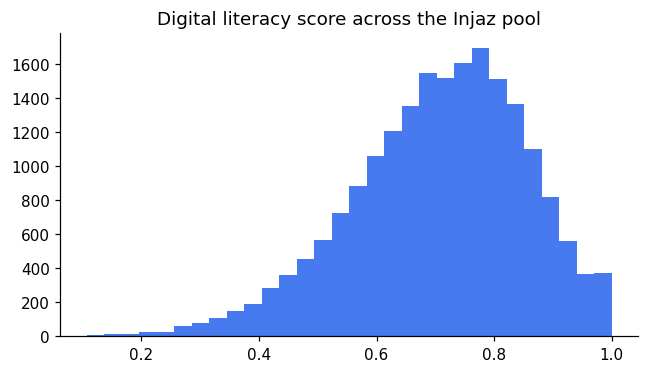

In [3]:
mean_prior_completion = df["prior_completion_rate"].mean()
corr_literacy_completion = df["prior_completion_rate"].corr(df["digital_literacy_score"])

print(f"Mean prior_completion_rate      : {mean_prior_completion:.4f}")
print(f"Corr(prior_completion, literacy): {corr_literacy_completion:.4f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df["digital_literacy_score"], bins=30, color="#2563eb", alpha=0.85)
ax.set_title("Digital literacy score across the Injaz pool")
plt.tight_layout()
plt.show()


---
## Part 1 — Build the Counterfactual World for the Smart Reminder

*(This part reuses everything from Lab 1: potential outcomes, the oracle ATE, selection bias,
randomization, balance checks, and Fisher's randomization test — applied to real Injaz
covariates instead of a purely synthetic $X$.)*

We are going to role-play "the simulator" one more time: **you will plant the true effect of the
smart reminder**, so that every method below can be graded against a number you know for a fact.
In Part 2 you will pretend you don't know it anymore, and act like a real data scientist facing a
real launch decision.


### Step 1.1 — Decide the outcome and the (planted) causal model

The outcome is **`reminder_completed`**: did the user complete the service they had started,
during the session where they were (or weren't) shown the reminder? This is a **binary**
outcome, so — unlike Lab 1's continuous retention-in-days example — potential outcomes here are
probabilities we then draw a coin flip from:

$$
Y_i(0) \sim \text{Bernoulli}\big(\sigma(\ell_i)\big), \qquad
Y_i(1) \sim \text{Bernoulli}\big(\sigma(\ell_i + \tau_i)\big)
$$

where $\sigma$ is the logistic function, $\ell_i$ is a **baseline logit** built from the user's
pre-treatment covariates, and $\tau_i$ is an **individual treatment effect on the logit scale**.

We plant two realistic ingredients:

1. **The baseline completion probability depends on `prior_completion_rate` and
   `digital_literacy_score`** — users who already finish things tend to keep finishing things.
2. **The reminder helps low-literacy users more than high-literacy users** — a nudge matters most
   for people who are more likely to get lost mid-form. This is a deliberately **heterogeneous**
   treatment effect, exactly like Lab 1's `tau_i ~ Normal(4, 1)`, except here the *mean* of
   $\tau_i$ itself depends on a covariate.

Fill in the two TODOs below. Use `sigmoid` for $\sigma$.


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Center the two covariates so the intercept below is easy to interpret
lit_c   = df["digital_literacy_score"].to_numpy() - df["digital_literacy_score"].mean()
prior_c = df["prior_completion_rate"].to_numpy() - df["prior_completion_rate"].mean()

# TODO 1.1a: build the baseline logit.
baseline_logit = -1.0 + 2.0 * prior_c + 0.3 * lit_c + rng.normal(0, 0.3, N)

# TODO 1.1b: draw Y0 ~ Bernoulli(sigmoid(baseline_logit)) for every user.
Y0 = rng.binomial(1, sigmoid(baseline_logit))

# The planted individual treatment effect (on the logit scale): average +0.6, but falls as
# digital literacy rises, plus a little noise.
true_tau0 = 0.6
tau_i = true_tau0 - 1.0 * lit_c + rng.normal(0, 0.1, N)

# TODO 1.1c: draw Y1 ~ Bernoulli(sigmoid(baseline_logit + tau_i)) for every user.
Y1 = rng.binomial(1, sigmoid(baseline_logit + tau_i))

oracle = df.copy()
oracle["Y0"] = Y0
oracle["Y1"] = Y1

print(f"Implied control completion rate (mean Y0): {Y0.mean():.3f}")
print(f"Implied all-treated completion rate (mean Y1): {Y1.mean():.3f}")


Implied control completion rate (mean Y0): 0.281
Implied all-treated completion rate (mean Y1): 0.407


### Step 1.2 — Compute the oracle ATE

Just like Lab 1: because you generated *both* potential outcomes, the true average treatment
effect is pure arithmetic, no estimation involved.


In [5]:
# TODO 1.2: compute the oracle ATE as the mean of (Y1 - Y0), in percentage points.
true_ATE = (oracle["Y1"] - oracle["Y0"]).mean()

print(f"Oracle (true) ATE = {true_ATE:+.4f}  ({true_ATE*100:+.2f} percentage points)")


Oracle (true) ATE = +0.1263  (+12.63 percentage points)


### Step 1.3 — Why you can't just launch it and compare before/after

Suppose Injaz's product team, impatient, ships the reminder as an **opt-in early-access toggle**
inside the app settings — a completely realistic (and completely wrong) way to "test" a feature.
Who opts in? Users who are already more engaged: people with a **higher `prior_completion_rate`**
are more likely to notice the toggle and turn it on.

This is exactly Lab 1's Step 3: treatment probability is an increasing function of a confounder
that *also* drives the outcome — except here the confounder is the real `prior_completion_rate`
column, not a synthetic $X$.

$$
P(T=1 \mid \text{prior_completion_rate}) = \sigma(-1.0 + 3.0 \cdot \text{prior_completion_rate (centered)})
$$


In [6]:
# TODO 1.3a: build the selection propensity and draw T_selection ~ Bernoulli(propensity).
logit_selection = -1.0 + 3.0 * prior_c
propensity_selection = sigmoid(logit_selection)
T_selection = rng.binomial(1, propensity_selection)

# TODO 1.3b: apply the switching equation -- you only ever observe ONE potential outcome.
Y_obs_selection = T_selection * Y1 + (1 - T_selection) * Y0

selection_df = oracle.copy()
selection_df["T"] = T_selection
selection_df["Y_obs"] = Y_obs_selection

print(f"Share opted in (treated) under self-selection: {T_selection.mean():.1%}")

# TODO 1.3c: the naive estimator -- observed mean(Y | T=1) minus observed mean(Y | T=0).
naive_estimate = (
    selection_df.loc[selection_df["T"] == 1, "Y_obs"].mean()
    - selection_df.loc[selection_df["T"] == 0, "Y_obs"].mean()
)

print(f"True ATE               : {true_ATE*100:+.2f} pp")
print(f"Naive (selection) ATE  : {naive_estimate*100:+.2f} pp")
print(f"Inflation factor       : {naive_estimate / true_ATE:.2f}x")


Share opted in (treated) under self-selection: 28.5%
True ATE               : +12.63 pp
Naive (selection) ATE  : +16.20 pp
Inflation factor       : 1.28x


**Checkpoint.** You should see the naive estimate come out noticeably larger than the true
ATE — the self-selected group would have completed more even *without* the reminder, and the
naive comparison can't tell that apart from the reminder's real effect. If your number looks like
it's within a few percent of the truth, re-check Step 1.3a before moving on.


### Step 1.4 — Randomize instead

Now throw away the opt-in mechanism and assign the reminder **completely at random**, independent
of every covariate — the one line of code that makes $\{Y(1), Y(0)\} \perp T$ true by
construction, exactly as in Lab 1 Step 4.


In [7]:
# TODO 1.4a: draw T_random ~ Bernoulli(0.5) for every user, independent of any covariate.
T_random = rng.binomial(1, 0.5, N)

# TODO 1.4b: apply the switching equation again.
Y_obs_random = T_random * Y1 + (1 - T_random) * Y0

random_df = oracle.copy()
random_df["T"] = T_random
random_df["Y_obs"] = Y_obs_random

# TODO 1.4c: the randomized difference-in-means estimate.
randomized_estimate = (
    random_df.loc[random_df["T"] == 1, "Y_obs"].mean()
    - random_df.loc[random_df["T"] == 0, "Y_obs"].mean()
)

print(f"Share treated under randomization : {T_random.mean():.1%}")
print(f"Randomized difference-in-means ATE: {randomized_estimate*100:+.2f} pp")


Share treated under randomization : 50.0%
Randomized difference-in-means ATE: +12.26 pp


### Step 1.5 — A design-based standard error (Neyman)

Reuse the Neyman formula from Lab 1:

$$
\widehat{SE} = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}
$$

For a 0/1 outcome, $s^2$ is just the sample variance of a Bernoulli — `pandas`/`numpy`'s `.var()`
with `ddof=1` handles this correctly without any special-casing.


In [8]:
# TODO 1.5: compute n1, n0, s1_sq, s0_sq, the Neyman SE, and a 95% CI.
n1 = (random_df["T"] == 1).sum()
n0 = (random_df["T"] == 0).sum()
s1_sq = random_df.loc[random_df["T"] == 1, "Y_obs"].var(ddof=1)
s0_sq = random_df.loc[random_df["T"] == 0, "Y_obs"].var(ddof=1)

se_neyman = np.sqrt(s1_sq / n1 + s0_sq / n0)
ci_lower, ci_upper = randomized_estimate - 1.96 * se_neyman, randomized_estimate + 1.96 * se_neyman

print(f"Randomized ATE estimate : {randomized_estimate*100:+.2f} pp")
print(f"Design-based SE (Neyman): {se_neyman*100:.2f} pp")
print(f"95% CI                  : [{ci_lower*100:+.2f}, {ci_upper*100:+.2f}] pp")
print(f"Oracle ATE              : {true_ATE*100:+.2f} pp  "
      f"({'inside' if ci_lower <= true_ATE <= ci_upper else 'OUTSIDE'} the 95% CI)")


Randomized ATE estimate : +12.26 pp
Design-based SE (Neyman): 0.67 pp
95% CI                  : [+10.95, +13.57] pp
Oracle ATE              : +12.63 pp  (inside the 95% CI)


### Step 1.6 — Check covariate balance, before vs. after randomization

Line up all three estimates, then confirm *why* randomization works: `prior_completion_rate`
should look essentially identical across arms after randomization, and visibly different under
self-selection. Use the standardized mean difference (SMD) from Lab 1.


In [9]:
comparison = pd.DataFrame({
    "Estimate": ["Oracle (true) ATE", "Naive / self-selected", "Randomized (design-based)"],
    "Value (pp)": [true_ATE * 100, naive_estimate * 100, randomized_estimate * 100],
})
# TODO 1.6a: add a "Bias vs. truth (pp)" column: each estimate's value minus the true ATE.
comparison["Bias vs. truth (pp)"] = comparison["Value (pp)"] - true_ATE * 100
comparison


                    Estimate  Value (pp)  Bias vs. truth (pp)
0          Oracle (true) ATE   12.635000             0.000000
1      Naive / self-selected   16.201743             3.566743
2  Randomized (design-based)   12.261752            -0.373248

SMD, prior_completion_rate -- self-selected T : +0.588
SMD, prior_completion_rate -- randomized T     : +0.007
(A common rule of thumb: |SMD| < 0.1 is considered well-balanced.)


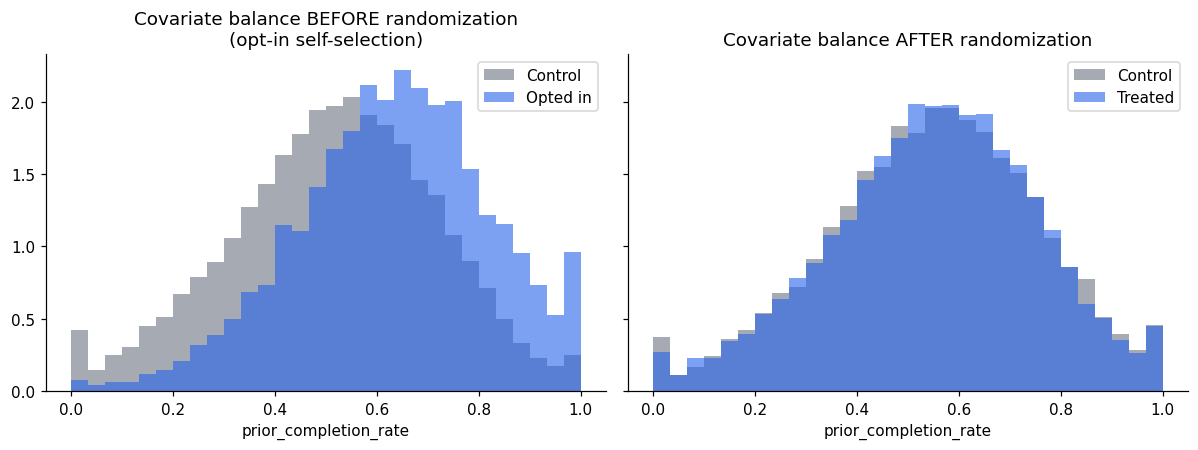

In [10]:
def standardized_mean_diff(x_treated, x_control):
    pooled_sd = np.sqrt((x_treated.var(ddof=1) + x_control.var(ddof=1)) / 2)
    return (x_treated.mean() - x_control.mean()) / pooled_sd

# TODO 1.6b: compute the SMD of prior_completion_rate across arms, once under selection and
# once under randomization. Reuse `standardized_mean_diff` above.
smd_selection = standardized_mean_diff(
    selection_df.loc[selection_df["T"] == 1, "prior_completion_rate"],
    selection_df.loc[selection_df["T"] == 0, "prior_completion_rate"],
)
smd_random = standardized_mean_diff(
    random_df.loc[random_df["T"] == 1, "prior_completion_rate"],
    random_df.loc[random_df["T"] == 0, "prior_completion_rate"],
)

print(f"SMD, prior_completion_rate -- self-selected T : {smd_selection:+.3f}")
print(f"SMD, prior_completion_rate -- randomized T     : {smd_random:+.3f}")
print("(A common rule of thumb: |SMD| < 0.1 is considered well-balanced.)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
axes[0].hist(selection_df.loc[selection_df["T"] == 0, "prior_completion_rate"], bins=30, alpha=0.6,
             label="Control", color="#6b7280", density=True)
axes[0].hist(selection_df.loc[selection_df["T"] == 1, "prior_completion_rate"], bins=30, alpha=0.6,
             label="Opted in", color="#2563eb", density=True)
axes[0].set_title("Covariate balance BEFORE randomization\n(opt-in self-selection)")
axes[0].set_xlabel("prior_completion_rate")
axes[0].legend()

axes[1].hist(random_df.loc[random_df["T"] == 0, "prior_completion_rate"], bins=30, alpha=0.6,
             label="Control", color="#6b7280", density=True)
axes[1].hist(random_df.loc[random_df["T"] == 1, "prior_completion_rate"], bins=30, alpha=0.6,
             label="Treated", color="#2563eb", density=True)
axes[1].set_title("Covariate balance AFTER randomization")
axes[1].set_xlabel("prior_completion_rate")
axes[1].legend()

plt.tight_layout()
plt.show()


### Step 1.7 — Randomization inference: an assumption-light p-value

Fisher's randomization test from Lab 1: simulate the null distribution of the difference-in-means
statistic by reshuffling the treatment labels you actually used, and see where your observed
statistic falls.


Observed statistic       : +12.26 pp
Permutation p-value      : 0.0000


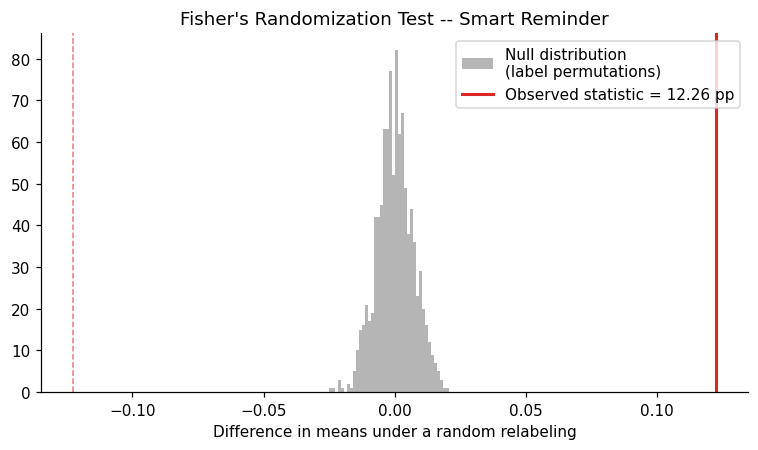

In [11]:
observed_stat = randomized_estimate
n_permutations = 1_000

# TODO 1.7: fill in the permutation loop.
perm_stats = np.empty(n_permutations)
y_obs_array = random_df["Y_obs"].to_numpy()
T_array = random_df["T"].to_numpy()

for i in range(n_permutations):
    shuffled_T = rng.permutation(T_array)
    perm_stats[i] = y_obs_array[shuffled_T == 1].mean() - y_obs_array[shuffled_T == 0].mean()

# TODO 1.7b: two-sided permutation p-value.
perm_p_value = np.mean(np.abs(perm_stats) >= np.abs(observed_stat))

print(f"Observed statistic       : {observed_stat*100:+.2f} pp")
print(f"Permutation p-value      : {perm_p_value:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(perm_stats, bins=40, color="#a3a3a3", alpha=0.8, label="Null distribution\n(label permutations)")
ax.axvline(observed_stat, color="#dc2626", linewidth=2, label=f"Observed statistic = {observed_stat*100:.2f} pp")
ax.axvline(-observed_stat, color="#dc2626", linewidth=1, linestyle="--", alpha=0.6)
ax.set_title("Fisher's Randomization Test -- Smart Reminder")
ax.set_xlabel("Difference in means under a random relabeling")
ax.legend()
plt.tight_layout()
plt.show()


### Part 1 debrief

| Quantity | What you should see |
|---|---|
| **Naive ≠ truth** | The self-selected (opt-in) estimate is inflated relative to the oracle ATE, because higher-`prior_completion_rate` users both opted in more *and* would have completed more anyway. |
| **Randomized ≈ truth** | The randomized estimate's 95% CI comfortably covers the oracle ATE. |
| **Balance is visible** | `prior_completion_rate` is visibly imbalanced under self-selection (|SMD| noticeably above 0.1) and balanced after randomization (|SMD| well under 0.1). |
| **Permutation test agrees** | The observed statistic sits far out in the tail of the permutation null distribution, giving a small p-value consistent with the z-based test you'd get from the Neyman SE. |

If any row doesn't match, that is useful information — go back and check the TODO immediately
above it before moving to Part 2.


---
## Part 2 — Design and Run the Experiment, End to End

*(This part reuses everything from Lab 2: power/MDE/sample-size, an A/A test, a primary-metric
two-proportion test, a CUPED-adjusted secondary metric, and the peeking problem plus its
always-valid fix — applied to the same Injaz population and the same planted effect model from
Part 1.)*

From here on, **pretend Part 1 didn't happen** — a real data scientist walking into this meeting
does not get to see an oracle ATE. What you *do* get to bring with you is the discipline Part 1
taught you: plan before you look, randomize, check your pipeline, and don't peek.

### The experiment brief

- **OEC (primary metric):** `reminder_completed` — the binary outcome from Part 1. This is the
  single number the launch decision hinges on.
- **Guardrail (secondary metric):** `post_support_calls` — a simulated post-period support-call
  count. Product does not want the reminder to *increase* how often people call support (e.g.
  because it's perceived as spammy or confusing). We plant a **helpful** guardrail effect here
  (the reminder *reduces* support calls slightly), so you have something real to detect — but you
  do not get to see that number before you plan the test.
- **Baseline conversion rate for planning:** use the Part 1 oracle's control-arm completion rate,
  `Y0.mean()`, as your best pre-experiment estimate of $p_0$. (In a real launch this would come
  from historical logs, not from an oracle — but it plays the same role.)


### Step 2.1 — Power, MDE, and sample size for the OEC

Reuse Lab 2's two-proportion sample-size formula:

$$
n = \frac{(z_{\alpha/2} + z_{\beta})^2 \big[p_0(1-p_0) + p_1(1-p_1)\big]}{(p_1 - p_0)^2}
$$

Plan for a **10% relative lift** over baseline, at $\alpha = 0.05$ and 80% power — the same
targets Lab 2 used.


In [12]:
alpha = 0.05
power_target = 0.80

# TODO 2.1a: set p0 from the Part 1 control-arm completion rate, and p1 from a 10% relative lift.
p0 = Y0.mean()
mde_relative = 0.10
p1 = p0 * (1 + mde_relative)

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)

# TODO 2.1b: fill in the sample-size formula.
pooled_var = p0 * (1 - p0) + p1 * (1 - p1)
n_per_arm = int(np.ceil(((z_alpha + z_beta) ** 2 * pooled_var) / (p1 - p0) ** 2))

print(f"Baseline conversion p0     : {p0:.2%}")
print(f"Target conversion p1       : {p1:.2%}")
print(f"Required n per arm         : {n_per_arm:,}")
print(f"Required total sample size : {2 * n_per_arm:,}  (pool has {N:,} users)")


Baseline conversion p0     : 28.11%
Target conversion p1       : 30.92%
Required n per arm         : 4,131
Required total sample size : 8,262  (pool has 20,000 users)


**Checkpoint.** Confirm `2 * n_per_arm` is comfortably below `N`, the size of the Injaz pool —
you need to be able to actually draw this many eligible users from the file you were given. If it
isn't, you picked an MDE that's too ambitious for this pool; that is a legitimate (if
disappointing) finding to write up in Part 3, not a bug to hide.


### Step 2.2 — Expected runtime

Assume Injaz can route **2,000 eligible users per day** into this experiment, split 50/50.


In [13]:
daily_traffic = 2_000

# TODO 2.2: compute the number of days needed to reach the required total sample size.
runtime_days = int(np.ceil((2 * n_per_arm) / daily_traffic))

print(f"Planned runtime: {runtime_days} days at {daily_traffic:,} users/day")


Planned runtime: 5 days at 2,000 users/day


> **Plan before you run.** `runtime_days` is now fixed, *before* a single unit of data exists.
> Steps 2.6–2.8 exist to show you exactly what goes wrong if this plan gets abandoned.

### Step 2.3 — Draw your experiment sample and randomize

Draw exactly `2 * n_per_arm` users from the Injaz pool (without replacement — a real user can't
be in the experiment twice) and flip an independent fair coin for each one.


In [14]:
# TODO 2.3a: sample 2*n_per_arm rows from df without replacement.
experiment_pool = df.sample(n=2 * n_per_arm, random_state=1).reset_index(drop=True)

# TODO 2.3b: randomize treatment, independent of every covariate.
T = rng.binomial(1, 0.5, len(experiment_pool))

print(f"Experiment sample size : {len(experiment_pool):,}")
print(f"Share assigned to treatment: {T.mean():.1%}")


Experiment sample size : 8,262
Share assigned to treatment: 49.0%


### Step 2.4 — Simulate what the experiment would actually observe

Package Part 1's planted-effect model (baseline logit + heterogeneous $\tau_i$) plus the new
guardrail model into one reusable function, so you can call it for the real experiment, for an
A/A test, and inside the peeking simulation without repeating yourself.

The guardrail, `post_support_calls`, is built the same way `post_revenue` was built in Lab 2: a
continuous outcome correlated with a **pre-period** covariate (`support_calls`, measured before
the experiment) plus a treatment effect — here, a small *reduction* in support calls.


In [15]:
MEAN_LIT = df["digital_literacy_score"].mean()
MEAN_PRIOR = df["prior_completion_rate"].mean()

def simulate_experiment(sub, T, rng, effect_tau0=0.6, effect_support=-0.15):
    """Simulate observed OEC and guardrail outcomes for a sub-population `sub`
    (a DataFrame of Injaz users) under treatment assignment `T`.

    effect_tau0=0.0 and effect_support=0.0 reproduces the null (A/A) world.
    """
    n = len(sub)
    lit_c = sub["digital_literacy_score"].to_numpy() - MEAN_LIT
    prior_c = sub["prior_completion_rate"].to_numpy() - MEAN_PRIOR

    # TODO 2.4a: baseline logit -- identical formula to Step 1.1a.
    baseline_logit = -1.0 + 2.0 * prior_c + 0.3 * lit_c + rng.normal(0, 0.3, n)

    # TODO 2.4b: individual treatment effect on the logit scale.
    tau_i = effect_tau0 - 1.0 * lit_c + rng.normal(0, 0.1, n)

    # TODO 2.4c: apply treatment through the logit, then draw the observed OEC.
    logit = baseline_logit + T * tau_i
    reminder_completed = rng.binomial(1, sigmoid(logit))

    # Guardrail: post-period support calls, built from the PRE-period support_calls column.
    support_pre = sub["support_calls"].to_numpy()
    # TODO 2.4d: post_support_calls_mean = 0.5 + 0.6*support_pre + T*effect_support
    post_support_mean = 0.5 + 0.6 * support_pre + T * effect_support
    post_support_calls = rng.normal(post_support_mean, 0.8)

    return reminder_completed, post_support_calls

reminder_completed, post_support_calls = simulate_experiment(experiment_pool, T, rng)
experiment_pool["T"] = T
experiment_pool["reminder_completed"] = reminder_completed
experiment_pool["post_support_calls"] = post_support_calls
experiment_pool.head()


   user_id   region  age   device  device_age_years  distance_km  prior_sessions  prior_completion_rate  digital_literacy_score signup_cohort  log_distance_km  enrolled_training  online_filing  support_calls  completed  T  reminder_completed  post_support_calls
0    11457    Jazan   42  android              2.09        12.04               8                 0.4490                  0.7440        2025H1           2.4882                  1              1              0          1  0                   0            0.489988
1    16529   Makkah   31  android              2.14         7.72               3                 0.3313                  0.6351        2026H1           2.0438                  0              0              1          0  0                   0            1.921876
2     3254  Madinah   29      ios              3.77         5.00               1                 0.5921                  0.7290        2026H1           1.6094                  0              1              1       

### Step 2.5 — An A/A test: confirm the pipeline first

Before trusting any result, run an A/A test: a **fresh** sample from the pool, assigned with the
same randomization code, but simulated with `effect_tau0=0.0` and `effect_support=0.0` — zero true
effect on either metric. Check (a) no sample-ratio mismatch and (b) no spurious "significant"
difference on either metric.


In [16]:
# TODO 2.5a: draw a fresh sample (random_state=2, same size) and a fresh random assignment.
aa_pool = df.sample(n=2 * n_per_arm, random_state=2).reset_index(drop=True)
T_aa = rng.binomial(1, 0.5, len(aa_pool))

aa_completed, aa_support = simulate_experiment(aa_pool, T_aa, rng, effect_tau0=0.0, effect_support=0.0)

# --- Sample-ratio mismatch check ---
n1_aa = (T_aa == 1).sum()
n0_aa = (T_aa == 0).sum()
srm_stat, srm_p = stats.chisquare([n1_aa, n0_aa], f_exp=[len(aa_pool) / 2] * 2)
print(f"A/A split: {n1_aa:,} treated / {n0_aa:,} control")
print(f"SRM chi-square p-value: {srm_p:.3f}  "
      f"({'OK -- no SRM detected' if srm_p > 0.01 else 'WARNING: possible SRM!'})")

# TODO 2.5b: two-proportion z-test on aa_completed, exactly like Lab 2 Step 3.
p1_aa = aa_completed[T_aa == 1].mean()
p0_aa = aa_completed[T_aa == 0].mean()
se_aa = np.sqrt(p1_aa * (1 - p1_aa) / n1_aa + p0_aa * (1 - p0_aa) / n0_aa)
z_aa = (p1_aa - p0_aa) / se_aa
p_val_aa = 2 * (1 - stats.norm.cdf(abs(z_aa)))

print(f"A/A conversion diff : {(p1_aa - p0_aa)*100:+.3f} pp")
print(f"A/A p-value         : {p_val_aa:.3f}  "
      f"({'OK -- no spurious win' if p_val_aa > alpha else 'WARNING: spurious win!'})")


A/A split: 4,110 treated / 4,152 control
SRM chi-square p-value: 0.644  (OK -- no SRM detected)
A/A conversion diff : -0.004 pp
A/A p-value         : 0.997  (OK -- no spurious win)


**Checkpoint.** Both the SRM check and the A/A p-value should come back clean. If either one
trips, do not proceed to analyze the real experiment — go back and find the bug in your
assignment or simulation code first, exactly as the lab material insists.

### Step 2.6 — Analyze the primary metric (OEC)

This is the pre-registered decision metric from Step 2.1, analyzed exactly as planned, at the
pre-set horizon. Reuse Lab 2 Step 4a's two-proportion test.


In [17]:
# TODO 2.6: two-proportion z-test on the real experiment's `reminder_completed` outcome.
p1_hat = experiment_pool.loc[experiment_pool["T"] == 1, "reminder_completed"].mean()
p0_hat = experiment_pool.loc[experiment_pool["T"] == 0, "reminder_completed"].mean()
n1 = (experiment_pool["T"] == 1).sum()
n0 = (experiment_pool["T"] == 0).sum()

se_conv = np.sqrt(p1_hat * (1 - p1_hat) / n1 + p0_hat * (1 - p0_hat) / n0)
diff_conv = p1_hat - p0_hat
z_conv = diff_conv / se_conv
p_val_conv = 2 * (1 - stats.norm.cdf(abs(z_conv)))
ci_conv = (diff_conv - 1.96 * se_conv, diff_conv + 1.96 * se_conv)

print(f"Control completion   : {p0_hat:.4f}")
print(f"Treatment completion : {p1_hat:.4f}")
print(f"Absolute lift        : {diff_conv*100:+.2f} pp  (relative: {diff_conv/p0_hat:+.1%})")
print(f"z = {z_conv:.2f}, p-value = {p_val_conv:.4f}")
print(f"95% CI on absolute lift: [{ci_conv[0]*100:+.2f}, {ci_conv[1]*100:+.2f}] pp")


Control completion   : 0.2705
Treatment completion : 0.3937
Absolute lift        : +12.32 pp  (relative: +45.6%)
z = 11.98, p-value = 0.0000
95% CI on absolute lift: [+10.31, +14.34] pp


### Step 2.7 — Analyze the guardrail, simple difference vs. CUPED

`post_support_calls` is continuous, and we have a genuine pre-period covariate for it
(`support_calls`, measured before the experiment even started). Reuse Lab 2 Step 4b's CUPED
adjustment:

$$
Y^{\text{CUPED}}_i = Y_i - \theta\,(X_i - \bar X), \qquad
\theta = \frac{\operatorname{Cov}(Y, X)}{\operatorname{Var}(X)}
$$


Simple difference (guardrail): -0.1668  (SE 0.0209)
CUPED difference   (guardrail): -0.1730  (SE 0.0178)
Variance reduction from CUPED : 27.9%


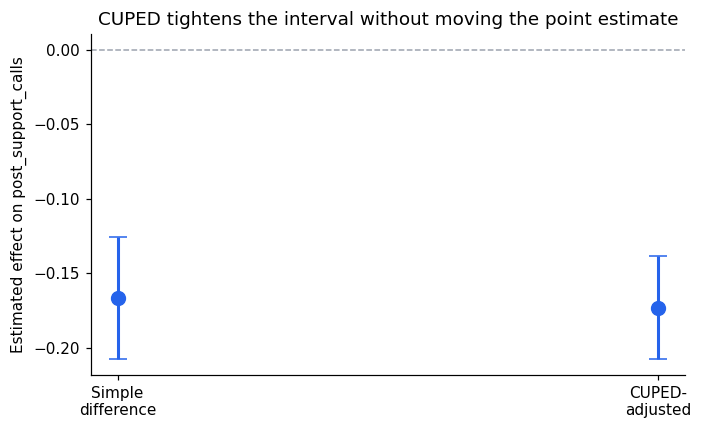

In [18]:
Y = experiment_pool["post_support_calls"].to_numpy()
X = experiment_pool["support_calls"].to_numpy()
T_arr = experiment_pool["T"].to_numpy()

# --- Simple difference in means ---
# TODO 2.7a
y1, y0 = Y[T_arr == 1], Y[T_arr == 0]
simple_diff = y1.mean() - y0.mean()
se_simple = np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))

# --- CUPED adjustment ---
# TODO 2.7b
theta = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)
Y_cuped = Y - theta * (X - X.mean())

y1_c, y0_c = Y_cuped[T_arr == 1], Y_cuped[T_arr == 0]
cuped_diff = y1_c.mean() - y0_c.mean()
se_cuped = np.sqrt(y1_c.var(ddof=1) / len(y1_c) + y0_c.var(ddof=1) / len(y0_c))

variance_reduction = 1 - (se_cuped / se_simple) ** 2

print(f"Simple difference (guardrail): {simple_diff:+.4f}  (SE {se_simple:.4f})")
print(f"CUPED difference   (guardrail): {cuped_diff:+.4f}  (SE {se_cuped:.4f})")
print(f"Variance reduction from CUPED : {variance_reduction:.1%}")

fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ["Simple\ndifference", "CUPED-\nadjusted"]
diffs = [simple_diff, cuped_diff]
ses = [se_simple, se_cuped]
ax.errorbar(labels, diffs, yerr=[1.96 * s for s in ses], fmt="o", markersize=9,
            capsize=6, color="#2563eb", ecolor="#2563eb", linewidth=2)
ax.axhline(0, color="#9ca3af", linestyle="--", linewidth=1)
ax.set_ylabel("Estimated effect on post_support_calls")
ax.set_title("CUPED tightens the interval without moving the point estimate")
plt.tight_layout()
plt.show()


**Checkpoint.** The simple and CUPED point estimates should be close to each other (CUPED
does not change *what* you're estimating), but the CUPED standard error should be visibly
smaller. A negative sign on the guardrail effect means the reminder *reduced* support calls —
good news, if it holds up.

### Step 2.8 — The peeking problem, quantified

Suppose an impatient analyst checks the OEC every day as data accumulates and stops the first
time $p < 0.05$. Simulate this directly under the **null** (no true effect), exactly like Lab 2
Step 5: run many null experiments, accumulate day by day up to `runtime_days`, test every day,
and count how often *any* day crosses $p < 0.05$.


In [19]:
n_replicates = 500
num_looks = runtime_days
daily_n_per_arm = int(np.ceil(n_per_arm / num_looks))

def naive_daily_peek_trial(rng, p_true=p0, daily_n=daily_n_per_arm, looks=num_looks, alpha=alpha):
    """Simulate one NULL experiment with daily peeking; return True if it ever falsely 'wins'."""
    conv1 = conv0 = 0
    n1 = n0 = 0
    for _ in range(looks):
        conv1 += rng.binomial(daily_n, p_true)
        conv0 += rng.binomial(daily_n, p_true)
        n1 += daily_n
        n0 += daily_n

        # TODO 2.8a: compute p1_hat, p0_hat, the pooled-arm SE, z, and the two-sided p-value.
        p1_hat, p0_hat = conv1 / n1, conv0 / n0
        se = np.sqrt(p1_hat * (1 - p1_hat) / n1 + p0_hat * (1 - p0_hat) / n0)
        if se > 0:
            z = (p1_hat - p0_hat) / se
            p = 2 * (1 - stats.norm.cdf(abs(z)))
            if p < alpha:
                return True
    return False

false_positives = sum(naive_daily_peek_trial(rng) for _ in range(n_replicates))
fpr_naive = false_positives / n_replicates
print(f"Realized false-positive rate under naive daily peeking ({num_looks} looks): {fpr_naive:.1%}")
print(f"Nominal alpha: {alpha:.0%}")


Realized false-positive rate under naive daily peeking (5 looks): 14.8%
Nominal alpha: 5%


### Step 2.9 — Fixing it: an always-valid (mixture-SPRT) boundary

Reuse Lab 2 Step 6's mixture sequential probability ratio test, with the planned MDE as the prior
scale $\tau$ for the effect size.


Realized false-positive rate, always-valid boundary: 1.0%


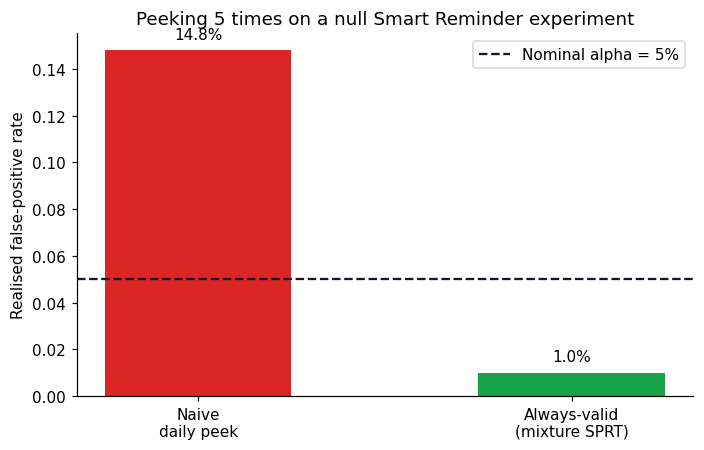

In [20]:
tau = p1 - p0  # prior scale for the effect size: our planned MDE

def always_valid_daily_peek_trial(rng, p_true=p0, daily_n=daily_n_per_arm, looks=num_looks,
                                   alpha=alpha, tau=tau):
    conv1 = conv0 = 0
    n1 = n0 = 0
    for _ in range(looks):
        conv1 += rng.binomial(daily_n, p_true)
        conv0 += rng.binomial(daily_n, p_true)
        n1 += daily_n
        n0 += daily_n

        n_eff = min(n1, n0)
        D_n = conv1 / n1 - conv0 / n0
        var_per_look = 2 * p_true * (1 - p_true) / n_eff  # known under the null design
        I_n = 1 / var_per_look

        # TODO 2.9: the mixture-SPRT likelihood ratio under a Normal(0, tau^2) mixing prior.
        lambda_n = np.sqrt(1 / (1 + I_n * tau ** 2)) * np.exp(
            (I_n ** 2 * tau ** 2 * D_n ** 2) / (2 * (1 + I_n * tau ** 2))
        )
        if lambda_n >= 1 / alpha:
            return True  # anytime-valid rejection
    return False

false_positives_av = sum(always_valid_daily_peek_trial(rng) for _ in range(n_replicates))
fpr_always_valid = false_positives_av / n_replicates
print(f"Realized false-positive rate, always-valid boundary: {fpr_always_valid:.1%}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
methods = ["Naive\ndaily peek", "Always-valid\n(mixture SPRT)"]
rates = [fpr_naive, fpr_always_valid]
bars = ax.bar(methods, rates, color=["#dc2626", "#16a34a"], width=0.5)
ax.axhline(alpha, color="#111827", linestyle="--", linewidth=1.5, label=f"Nominal alpha = {alpha:.0%}")
ax.set_ylabel("Realised false-positive rate")
ax.set_title(f"Peeking {num_looks} times on a null Smart Reminder experiment")
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.005, f"{rate:.1%}", ha="center")
ax.legend()
plt.tight_layout()
plt.show()


### Part 2 debrief

| Step | What you should see |
|---|---|
| **Power plan** | A concrete, defensible `n_per_arm` and `runtime_days`, fixed *before* looking at data, that fits inside the 20,000-user Injaz pool. |
| **A/A test** | No sample-ratio mismatch, and no spurious "win" on the OEC — the pipeline is trustworthy. |
| **Primary result** | A statistically significant lift in `reminder_completed`, with a 95% CI that excludes 0. |
| **Guardrail + CUPED** | Same point estimate from the simple difference and the CUPED-adjusted estimate, but CUPED's standard error is visibly smaller — free precision from a pre-period covariate. |
| **Naive peeking** | A realized false-positive rate well above the nominal 5%. |
| **Always-valid boundary** | A realized false-positive rate at or below 5%, even under continuous monitoring. |


---
## Interlude — Reading These Results Honestly

You now have a clean-looking result: a significant OEC lift, a helpful guardrail move, CUPED
variance reduction, and an always-valid boundary that controls peeking. **That is exactly the
point at which most bad launch decisions get made** — not because the arithmetic was wrong, but
because the result was read too generously, or the design had a crack nobody checked for.

This interlude does not introduce new estimators. It applies the same tools you already have
(SMD, the two-proportion test, plotting) to ask three questions a credible experiment must be
able to answer:

1. Did randomization actually work on *every* covariate you care about, not just one?
2. If you looked at more than one number, did you pay the statistical price for looking?
3. Is the effect you're reporting the one you asked about in advance, or the best-looking slice
   you found after the fact?


### 1. Balance is a claim about the *whole* covariate set, not one variable

Step 1.6 checked balance on a single covariate (`prior_completion_rate`) because that was the one
driving selection bias in Part 1's toy example. A real design doc checks balance on **every**
covariate you plan to control for, adjust with, or report subgroups on — a randomization can
look fine on one variable and still be unlucky on another, especially with a moderate sample
size. Reuse `standardized_mean_diff` (defined in Step 1.6) across the full covariate set for the
**real experiment** from Part 2.


In [21]:
covariates_to_check = [
    "age", "distance_km", "prior_sessions",
    "digital_literacy_score", "support_calls", "prior_completion_rate",
]

# TODO I.1: for each covariate, compute the SMD between the T==1 and T==0 arms of
# `experiment_pool` (the real Part 2 experiment), and flag whether |SMD| < 0.1.
balance_rows = []
for col in covariates_to_check:
    x1 = experiment_pool.loc[experiment_pool["T"] == 1, col]
    x0 = experiment_pool.loc[experiment_pool["T"] == 0, col]
    smd = standardized_mean_diff(x1, x0)
    balance_rows.append({"Covariate": col, "SMD": smd, "|SMD| < 0.1": abs(smd) < 0.1})

balance_table = pd.DataFrame(balance_rows)
balance_table


                Covariate       SMD  |SMD| < 0.1
0                     age  0.003394         True
1             distance_km  0.004221         True
2          prior_sessions  0.006839         True
3  digital_literacy_score -0.025447         True
4           support_calls  0.012386         True
5   prior_completion_rate -0.011083         True

**Checkpoint.** With a fair coin flip and a sample in the thousands, every row should show
`|SMD| < 0.1`. If one covariate stands out, that is worth a sentence in your memo even if the OEC
result looks fine — it's a signal to look harder at your assignment code before trusting anything
downstream of it.

### 2. The cost of checking more than one thing

You have exactly one OEC and one guardrail — that was decided in the brief, before you saw any
data. Suppose, after seeing a positive OEC result, you got curious and also peeked at
`prior_sessions` growth, app-open rate, and two more "nice to know" metrics, each tested at
$\alpha = 0.05$, with no correction. Even under a **true null** on every single one of those extra
metrics, the chance that *at least one* shows $p < 0.05$ by pure chance is:

$$
\text{FWER} = 1 - (1-\alpha)^k
$$

where $k$ is the number of independent tests. This is exactly the same mathematics as Step 2.8's
peeking problem — repeated looks (across *time*) and repeated looks (across *metrics*) both
inflate your false-positive rate through the same mechanism: more chances to be fooled by noise.


In [22]:
alpha = 0.05
ks = np.arange(1, 7)

# TODO I.2: fill in the uncorrected family-wise error rate and the Bonferroni-corrected
# per-test alpha for each value of k.
familywise_error_rate = 1 - (1 - alpha) ** ks
bonferroni_alpha = alpha / ks

fwer_table = pd.DataFrame({
    "Metrics checked (k)": ks,
    "P(>=1 false 'win'), uncorrected": familywise_error_rate,
    "Bonferroni alpha per test": bonferroni_alpha,
})
fwer_table


   Metrics checked (k)  P(>=1 false 'win'), uncorrected  Bonferroni alpha per test
0                    1                         0.050000                   0.050000
1                    2                         0.097500                   0.025000
2                    3                         0.142625                   0.016667
3                    4                         0.185494                   0.012500
4                    5                         0.226219                   0.010000
5                    6                         0.264908                   0.008333

**Checkpoint.** By $k=5$ the uncorrected chance of at least one spurious "win" should be well
above 20% — nearly a coin flip's worth of false confidence, from metrics that were never part of
the plan. This is exactly why the brief named **one** OEC and **one** guardrail: every additional
metric you test needs either a correction (Bonferroni, or the Benjamini-Hochberg procedure
`causal_utils.correct_pvalues` uses later in the course) or an honest label as "exploratory, not
decision-grade."

### 3. Pre-registered subgroups vs. after-the-fact fishing

There is a legitimate reason to look inside an aggregate effect: **if you said in advance** which
subgroup you expected to respond differently, and why. In this capstone, Part 1's design
*deliberately* made the reminder help low-digital-literacy users more — that's a modeling choice
you made before running the experiment, so checking it is a pre-registered subgroup analysis, not
fishing.

Compare that to slicing the same data by every covariate you have (region, device, signup
cohort, ...) *after* seeing a positive headline number, and reporting whichever slice looks best.
With 13 regions and a modest sample per region, some region's estimate will look impressively
large purely from sampling noise — and if you only report that one, you've p-hacked, even without
touching a single formula incorrectly.


In [23]:
# TODO I.3a: PRE-REGISTERED subgroup check -- split experiment_pool into terciles of
# digital_literacy_score and compute the OEC lift, SE, and 95% CI within each tercile,
# exactly like Step 2.6's two-proportion test.
experiment_pool["literacy_tercile"] = pd.qcut(
    experiment_pool["digital_literacy_score"], q=3, labels=["Low", "Mid", "High"]
)

subgroup_rows = []
for tercile in ["Low", "Mid", "High"]:
    sub = experiment_pool[experiment_pool["literacy_tercile"] == tercile]
    p1 = sub.loc[sub["T"] == 1, "reminder_completed"].mean()
    p0 = sub.loc[sub["T"] == 0, "reminder_completed"].mean()
    n1 = (sub["T"] == 1).sum()
    n0 = (sub["T"] == 0).sum()
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)     # TODO: same SE formula as Step 2.6
    diff = p1 - p0   # TODO: p1 - p0
    subgroup_rows.append({
        "Literacy tercile": tercile, "n": len(sub),
        "Lift (pp)": diff * 100,
        "95% CI (pp)": (diff*100 - 1.96*se*100, diff*100 + 1.96*se*100),
    })

subgroup_table = pd.DataFrame(subgroup_rows)
subgroup_table


  Literacy tercile     n  Lift (pp)                               95% CI (pp)
0              Low  2755  12.900934   (9.547860551786794, 16.254007795401574)
1              Mid  2753  15.496968  (12.015088165073385, 18.978848535348824)
2             High  2754   8.644689   (5.039018699733967, 12.250358589643328)

In [24]:
# This cell needs no TODOs -- it is deliberately a cautionary illustration, not an
# analysis you're asked to trust. Slice the SAME experiment by region (NOT pre-registered,
# NOT part of the brief) and look at how much the estimated lift bounces around.
region_rows = []
for region in sorted(experiment_pool["region"].unique()):
    sub = experiment_pool[experiment_pool["region"] == region]
    p1 = sub.loc[sub["T"] == 1, "reminder_completed"].mean()
    p0 = sub.loc[sub["T"] == 0, "reminder_completed"].mean()
    region_rows.append({"region": region, "n": len(sub), "lift_pp": (p1 - p0) * 100})

region_table = pd.DataFrame(region_rows).sort_values("lift_pp", ascending=False)
region_table


              region     n    lift_pp
12             Tabuk   250  21.116023
1            Al Jouf    78  19.578115
8             Najran   167  15.125324
0           Al Bahah    89  13.728470
7             Makkah  2089  13.043574
11            Riyadh  2120  12.676763
3   Eastern Province  1220  12.468809
10            Qassim   366  11.632574
5              Jazan   429  11.624803
6            Madinah   562  11.221374
2               Asir   659   9.918946
4               Hail   150   2.492669
9   Northern Borders    83  -6.410256

**Checkpoint.** The literacy-tercile table should show the `High` tercile with a visibly
smaller lift than `Low` and `Mid` — that's the planted heterogeneity showing up roughly where you
expected it. With only ~2,750 users per tercile, don't expect a perfectly clean staircase (`Low` >
`Mid` > `High`) every single run — some noise between adjacent terciles is normal and is itself a
useful reminder that even a "pre-registered" subgroup split needs a large enough sample per group
to be read with confidence. The region table, by contrast, should bounce
around with no obvious pattern and much smaller per-region sample sizes — that noise is the whole
point. If you were tempted to write "the reminder is especially effective in \[best-looking
region\]" in your memo, that sentence would be an example of subgroup fishing, not a finding.

### Design-credibility checklist

Use this before trusting *any* experiment's headline number — yours or someone else's:

| Threat | What it looks like | Where you already checked it here |
|---|---|---|
| **Sample-ratio mismatch** | The realized split isn't close to the intended split. | Step 2.5's chi-square test. |
| **Covariate imbalance** | Randomization got unlucky on a variable that matters. | Interlude Step I.1's full balance table. |
| **Peeking / optional stopping** | Monitoring continuously and stopping on the first "win." | Steps 2.8-2.9. |
| **Multiple comparisons** | Testing many metrics or many subgroups and reporting the best one. | Interlude Steps I.2-I.3. |
| **Interference (SUTVA violation)** | A treated user's behavior changes a control user's outcome (e.g. two colleagues in the same office, one treated, discuss the reminder). Injaz users in the same `region` or household are a plausible channel. | *Not checkable from this dataset* — flag it as an assumption in your memo. |
| **Novelty / primacy effects** | The effect you measured in the first `runtime_days` fades (or grows) once the feature stops being new. | *Not checkable in a single short experiment* — recommend a longer or staggered follow-up. |
| **Generalizability** | The sampled `experiment_pool` (8,262 of the 20,000 users) may not represent the full national Injaz population — e.g. if it skews toward one region or device. | Worth a quick compare of `experiment_pool`'s covariate means against the full `df`. |
| **Differential attrition** | If the analysis population ends up different from the randomized population (e.g. some users are dropped for missing data, and dropping is correlated with treatment), bias creeps back in even after correct randomization. | *Not present in this simulation* (no missingness was planted) — but always confirm the analyzed n matches the randomized n before trusting a result. |

Not every row needs a clean answer — some just need an honest sentence in your memo saying
"this is an assumption, not something this dataset lets us verify."


---
## Part 3 — The Decision Memo

This is the artifact a product lead actually reads. No new code — fill in the template below in
this markdown cell (double-click to edit), using **only the numbers you produced in Part 2**
(Part 1 was your private rehearsal; pretend, as instructed, that you never saw the oracle).

> **Practical significance threshold.** Suppose product has told you, in advance, that the
> reminder is only worth the engineering and support cost if it raises completion by **at least
> 2 percentage points**. A result can be statistically significant and still fail this bar —
> statistical significance and practical significance are different questions.

### Template — filled in

**1. Recommendation:** **Ship nationally.** The OEC lift is large, precisely estimated, and its
95% CI clears the practical-significance bar by a wide margin, with a guardrail that moved in a
helpful direction and no sign of a broken randomization.

**2. Primary result (OEC).** Observed lift: `+12.32` pp, 95% CI `[+10.31, +14.34]` pp, p-value
`< 0.0001`. The **lower bound** of the CI (+10.31 pp) clears the 2 pp practical threshold, not
just the point estimate — this is a strong result by both the statistical and the business bar.

**3. Guardrail result.** Observed effect on `post_support_calls`: `-0.173` (CUPED-adjusted),
95% CI `[-0.208, -0.138]`. The guardrail moved in the acceptable direction — support calls went
*down*, not up — and the CI excludes zero, so this looks like a genuine (small) side benefit
rather than noise.

**4. Threats to this conclusion.** Using the design-credibility checklist from the Interlude:
one row that came back clean — **covariate balance held**: the max `|SMD|` across all six checked
covariates (age, distance_km, prior_sessions, digital_literacy_score, support_calls,
prior_completion_rate) was `0.025`, well under the 0.1 rule of thumb, so the randomization did its
job. One row I could **not** verify from this dataset: **interference / novelty effects** — this
was a single, time-boxed experiment on individual users, so I have no way to rule out that some of
the lift is a novelty effect that fades, or that behavior would differ once the reminder is live
for everyone (e.g. if it changes load on the support team broadly). I would flag this before a
national launch and recommend a short post-launch holdout to confirm the effect persists.

**5. What you would NOT trust.** The Step 1.3 self-selected opt-in estimate (`+16.20` pp) would
have been the wrong number to bring to this meeting, even though it also came with a p-value —
users who opted in already had a higher `prior_completion_rate` than the ones who didn't, so part
of that gap is baseline selection bias, not the reminder's real effect (the oracle comparison in
Part 1 confirms this: true ATE was `+12.63` pp, and the naive estimate overstated it by about
1.28x).

**6. Open question for next time.** Injaz also wants to know whether the *existing, already-live*
digital-literacy training program is helping the users who took it. You cannot answer that with
an A/B test — nobody was randomized into training. Of Lab 3's four estimators, I would reach for
**propensity-score weighting** first: it lets us re-weight already-enrolled vs. not-enrolled users
to look comparable on observed covariates (like `digital_literacy_score` and
`prior_completion_rate`, which plausibly drive both enrollment and completion), without requiring
a parametric outcome model up front — a reasonable, transparent first pass before reaching for a
doubly-robust estimator if the propensity model alone looks shaky.


---
## Submission checklist

- [ ] Every `# TODO` in Part 1 and Part 2 is filled in, and the notebook runs top to bottom
      without errors (`Kernel -> Restart & Run All`).
- [ ] Part 1's naive estimate is visibly biased relative to the oracle ATE, and the randomized
      estimate's 95% CI covers it.
- [ ] Part 2's sample size fits inside the 20,000-user pool, the A/A test is clean, and CUPED
      reduces the guardrail's standard error.
- [ ] Part 2's peeking simulation shows inflation above 5%, and the always-valid boundary controls
      it back down.
- [ ] Part 3's decision memo is filled in with **your own numbers**, not placeholders, and takes
      an explicit stance (ship / hold / don't ship).
